   Unnamed: 0 Unnamed: 1            Unnamed: 2  \
0         NaN       Data              Variable   
1         NaN     E Comm            CustomerID   
2         NaN     E Comm                 Churn   
3         NaN     E Comm                Tenure   
4         NaN     E Comm  PreferredLoginDevice   

                           Unnamed: 3  
0                         Discerption  
1                  Unique customer ID  
2                          Churn Flag  
3  Tenure of customer in organization  
4  Preferred login device of customer  
Shape before dropping NaN values: (21, 4)
Number of NaN values: 21
Shape after handling NaN values: (21, 4)


D:\Anaconda\Lib\site-packages\sklearn\utils\extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
D:\Anaconda\Lib\site-packages\sklearn\utils\extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
D:\Anaconda\Lib\site-packages\sklearn\utils\extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


Accuracy: 0.0

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       1.0
           3       0.00      0.00      0.00       0.0
           4       0.00      0.00      0.00       0.0
           5       0.00      0.00      0.00       1.0
           7       0.00      0.00      0.00       1.0
           9       0.00      0.00      0.00       0.0
          15       0.00      0.00      0.00       0.0
          17       0.00      0.00      0.00       1.0
          20       0.00      0.00      0.00       1.0

    accuracy                           0.00       5.0
   macro avg       0.00      0.00      0.00       5.0
weighted avg       0.00      0.00      0.00       5.0



D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricW

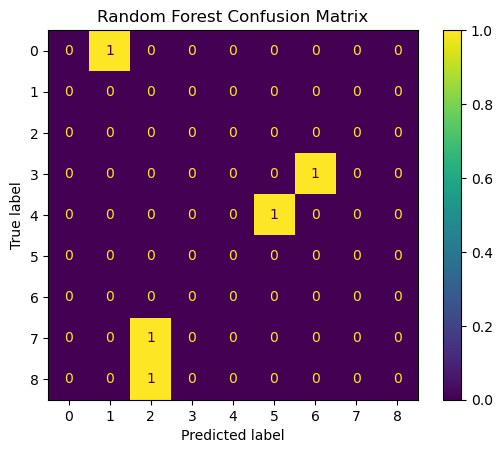

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

df = pd.read_csv("E Commerce Dataset.csv")
print(df.head())

# Check for NaN values before dropping
print(f"Shape before dropping NaN values: {df.shape}")
print(f"Number of NaN values: {df.isna().sum().sum()}")

# Instead of dropping all NaN values, consider more selective approaches
# Option 1: Drop only if a certain percentage of the row is NaN
df = df.dropna(thresh=len(df.columns) * 0.5)  # Keep rows with at least 50% non-NaN values

# Option 2: Fill NaN values instead of dropping
# For numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# For categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])

print(f"Shape after handling NaN values: {df.shape}")

# Check if we have enough data for splitting
if len(df) < 5:  # Arbitrary small number for checking
    raise ValueError("Dataset too small after handling NaN values")

le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)  # Updated parameter name
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

   Unnamed: 0 Unnamed: 1            Unnamed: 2  \
0         NaN       Data              Variable   
1         NaN     E Comm            CustomerID   
2         NaN     E Comm                 Churn   
3         NaN     E Comm                Tenure   
4         NaN     E Comm  PreferredLoginDevice   

                           Unnamed: 3  
0                         Discerption  
1                  Unique customer ID  
2                          Churn Flag  
3  Tenure of customer in organization  
4  Preferred login device of customer  
Shape before dropping NaN values: (21, 4)
Number of NaN values: 21
Shape after handling NaN values: (21, 4)


D:\Anaconda\Lib\site-packages\sklearn\utils\extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
D:\Anaconda\Lib\site-packages\sklearn\utils\extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
D:\Anaconda\Lib\site-packages\sklearn\utils\extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


Accuracy: 0.0

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       1.0
           3       0.00      0.00      0.00       0.0
           4       0.00      0.00      0.00       0.0
           5       0.00      0.00      0.00       1.0
           7       0.00      0.00      0.00       1.0
           9       0.00      0.00      0.00       0.0
          15       0.00      0.00      0.00       0.0
          17       0.00      0.00      0.00       1.0
          20       0.00      0.00      0.00       1.0

    accuracy                           0.00       5.0
   macro avg       0.00      0.00      0.00       5.0
weighted avg       0.00      0.00      0.00       5.0



D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricW

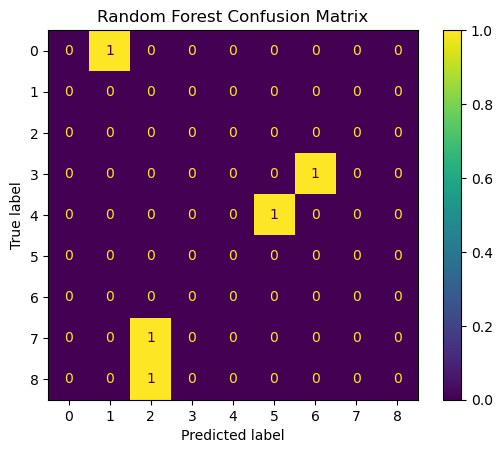

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

df = pd.read_csv("E Commerce Dataset.csv")
print(df.head())

# Check for NaN values before dropping
print(f"Shape before dropping NaN values: {df.shape}")
print(f"Number of NaN values: {df.isna().sum().sum()}")

# Instead of dropping all NaN values, consider more selective approaches
# Option 1: Drop only if a certain percentage of the row is NaN
df = df.dropna(thresh=len(df.columns) * 0.5)  # Keep rows with at least 50% non-NaN values

# Option 2: Fill NaN values instead of dropping
# For numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# For categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])

print(f"Shape after handling NaN values: {df.shape}")

# Check if we have enough data for splitting
if len(df) < 5:  # Arbitrary small number for checking
    raise ValueError("Dataset too small after handling NaN values")

le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)  # Updated parameter name
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [10]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    fbeta_score
)

# ==============================
# 2. LOAD DATA
# ==============================
df = pd.read_csv("E Commerce Dataset.csv")
print(df.head())

# ==============================
# 3. PREPROCESSING
# ==============================
# Check for null values before dropping
print(f"Shape before dropping nulls: {df.shape}")
print(f"Null values in each column:\n{df.isnull().sum()}")

# Instead of dropping all rows with any null values, consider more targeted approaches
# Option 1: Drop only if too many nulls in a row
df = df.dropna(thresh=len(df.columns) - 2)  # Keep rows with at most 2 null values

# Option 2: Fill nulls instead of dropping
# For numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# For categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])

print(f"Shape after handling nulls: {df.shape}")

# Ensure we have data before proceeding
if len(df) == 0:
    raise ValueError("Dataset is empty after preprocessing. Check your data source.")

le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==============================
# 4. TRAIN ADABOOST
# ==============================
ab = AdaBoostClassifier(n_estimators=100, random_state=42)
ab.fit(X_train, y_train)

y_pred = ab.predict(X_test)

# ==============================
# 5. EVALUATION
# ==============================
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# F-beta scores
f1 = fbeta_score(y_test, y_pred, beta=1, average='weighted')
print("F1 Score (beta=1):", f1)

f05 = fbeta_score(y_test, y_pred, beta=0.5, average='weighted')
print("F0.5 Score (precision-focused):", f05)

f2 = fbeta_score(y_test, y_pred, beta=2, average='weighted')
print("F2 Score (recall-focused):", f2)

# ==============================
# 6. CONFUSION MATRIX
# ==============================
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("AdaBoost Confusion Matrix")
plt.show()

   Unnamed: 0 Unnamed: 1            Unnamed: 2  \
0         NaN       Data              Variable   
1         NaN     E Comm            CustomerID   
2         NaN     E Comm                 Churn   
3         NaN     E Comm                Tenure   
4         NaN     E Comm  PreferredLoginDevice   

                           Unnamed: 3  
0                         Discerption  
1                  Unique customer ID  
2                          Churn Flag  
3  Tenure of customer in organization  
4  Preferred login device of customer  
Shape before dropping nulls: (21, 4)
Null values in each column:
Unnamed: 0    21
Unnamed: 1     0
Unnamed: 2     0
Unnamed: 3     0
dtype: int64
Shape after handling nulls: (21, 4)


D:\Anaconda\Lib\site-packages\sklearn\utils\extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
D:\Anaconda\Lib\site-packages\sklearn\utils\extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
D:\Anaconda\Lib\site-packages\sklearn\utils\extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


ValueError: Input X contains NaN.
AdaBoostClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values